No files found for ATMOS on July 22–23, 2024.

=== Processing NU: 2 files ===
NU – temperature: Max = 27.60 at 2024-07-28 22:59:20


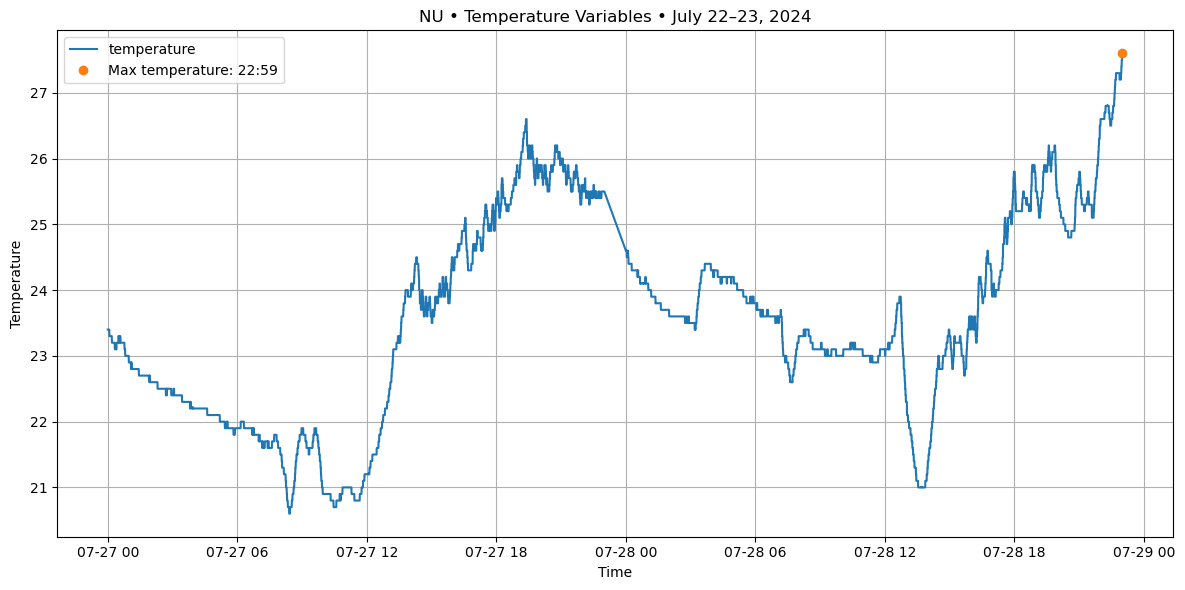


=== Processing NEIU: 2 files ===
NEIU – temperature: Max = 28.80 at 2024-07-28 19:30:20


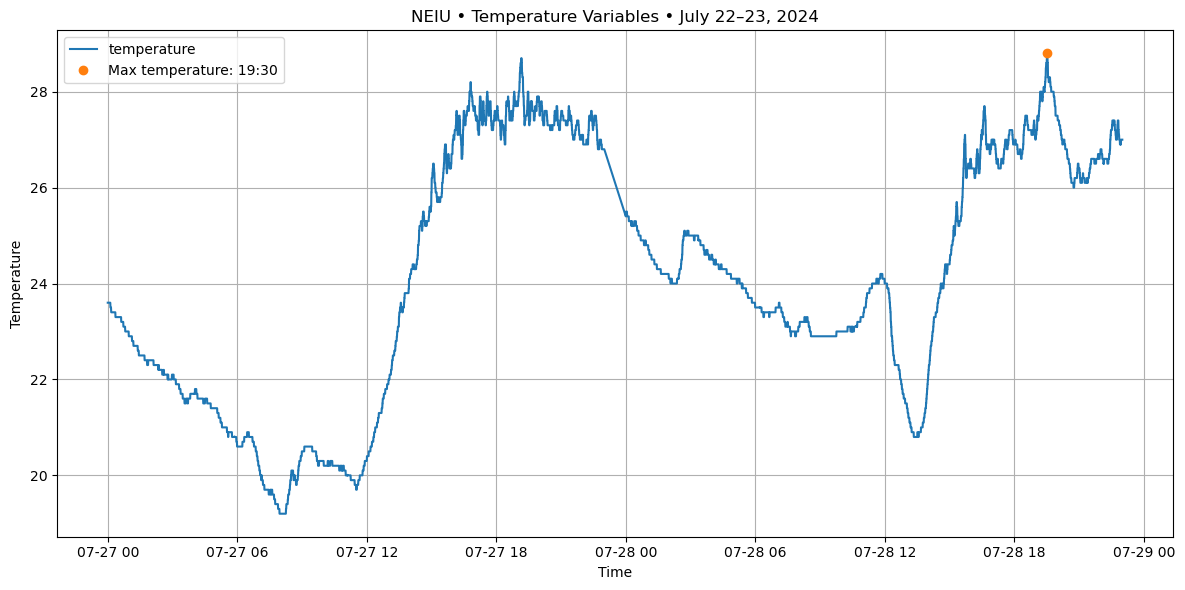


=== Processing UIC: 2 files ===
UIC – temperature: Max = 28.20 at 2024-07-28 19:25:50


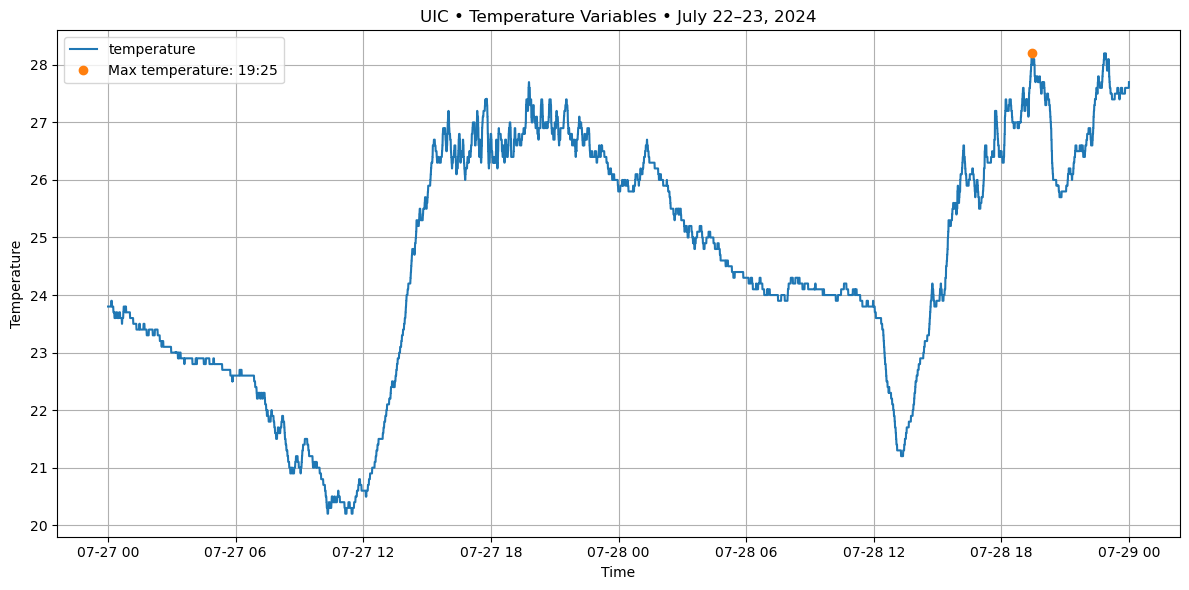

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Configuration
stations = ["ATMOS", "NU", "NEIU", "UIC"]
dates_of_interest = ["20240727", "20240728"]
base_path = "/nfs/gce/projects/crocus/data/ingested-data/long-term-sites"
temp_keywords = ["temp", "temperature", "tmp"]  # match variable names

# Process each station
for station in stations:
    station_lower = station.lower()
    station_path = Path(base_path) / station_lower / f"{station_lower}-wxt-a1"

    # Gather matching NetCDF files
    nc_files = sorted(
        [
            f
            for f in station_path.glob("*.nc")
            if any(date in f.name for date in dates_of_interest)
        ]
    )

    if not nc_files:
        print(f"No files found for {station} on July 22–23, 2024.")
        continue

    print(f"\n=== Processing {station}: {len(nc_files)} files ===")

    # Load and concat
    ds_all = xr.concat([xr.open_dataset(f) for f in nc_files], dim="time")

    # Identify temperature variables
    temp_vars = [
        v for v in ds_all.data_vars if any(k in v.lower() for k in temp_keywords)
    ]

    if not temp_vars:
        print(f"No temperature variables found in {station} data.")
        continue

    # Plot
    plt.figure(figsize=(12, 6))
    for var in temp_vars:
        data = ds_all[var]
        if "time" not in data.dims:
            continue
        times = data["time"]
        values = data.values

        plt.plot(times, values, label=var)

        # Max temperature info
        max_idx = values.argmax()
        max_time = times[max_idx].values
        max_val = values[max_idx]
        max_time_str = pd.to_datetime(str(max_time))

        print(f"{station} – {var}: Max = {max_val:.2f} at {max_time_str}")

        # Mark max on plot
        plt.plot(max_time, max_val, "o", label=f"Max {var}: {max_time_str:%H:%M}")

    plt.title(f"{station} • Temperature Variables • July 22–23, 2024")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2]:
import xarray as xr
from pathlib import Path

# Configuration
station = "UIC"
dates_of_interest = ["20240722", "20240723", "20240727", "20240728"]
base_path = "/nfs/gce/projects/crocus/data/ingested-data/long-term-sites"

# Build path for UIC
station_lower = station.lower()
station_path = Path(base_path) / station_lower / f"{station_lower}-wxt-a1"

# Gather matching NetCDF files for the 22nd, 23rd, 27th, and 28th
nc_files = sorted(
    [
        f
        for f in station_path.glob("*.nc")
        if any(date in f.name for date in dates_of_interest)
    ]
)

if not nc_files:
    print(f"No files found for {station} on the specified dates.")
else:
    # Open and concatenate all selected files along the time dimension
    ds_all = xr.concat([xr.open_dataset(f) for f in nc_files], dim="time")
    print(ds_all)

<xarray.Dataset> Size: 3MB
Dimensions:        (time: 34560)
Coordinates:
  * time           (time) datetime64[ns] 276kB 2024-07-22 ... 2024-07-28T23:5...
Data variables:
    temperature    (time) float64 276kB 24.3 24.3 24.3 24.3 ... 27.6 27.65 27.7
    humidity       (time) float64 276kB 66.8 66.8 66.8 66.8 ... 68.5 68.62 68.7
    pressure       (time) float64 276kB 996.4 996.4 996.4 ... 991.4 991.4 991.4
    rainfall       (time) float64 276kB 135.8 135.8 135.8 ... 147.2 147.2 147.2
    dewpoint       (time) float64 276kB 17.74 17.74 17.74 ... 21.29 21.37 21.43
    wetbulb        (time) float64 276kB 19.76 19.76 19.76 ... 22.98 23.05 23.1
    wind_dir_10s   (time) float64 276kB 84.79 90.38 83.62 ... 114.3 153.9 144.3
    wind_mean_10s  (time) float64 276kB 1.403 1.354 1.214 ... 1.45 1.293 0.9188
    wind_max_10s   (time) float64 276kB 1.6 1.6 1.5 1.5 2.4 ... 1.9 1.6 1.5 1.3
Attributes:
    conventions:  CF 1.10
    WSN:          W096
    site_ID:      UIC
    CAMS_tag:     CMS-WXT-01

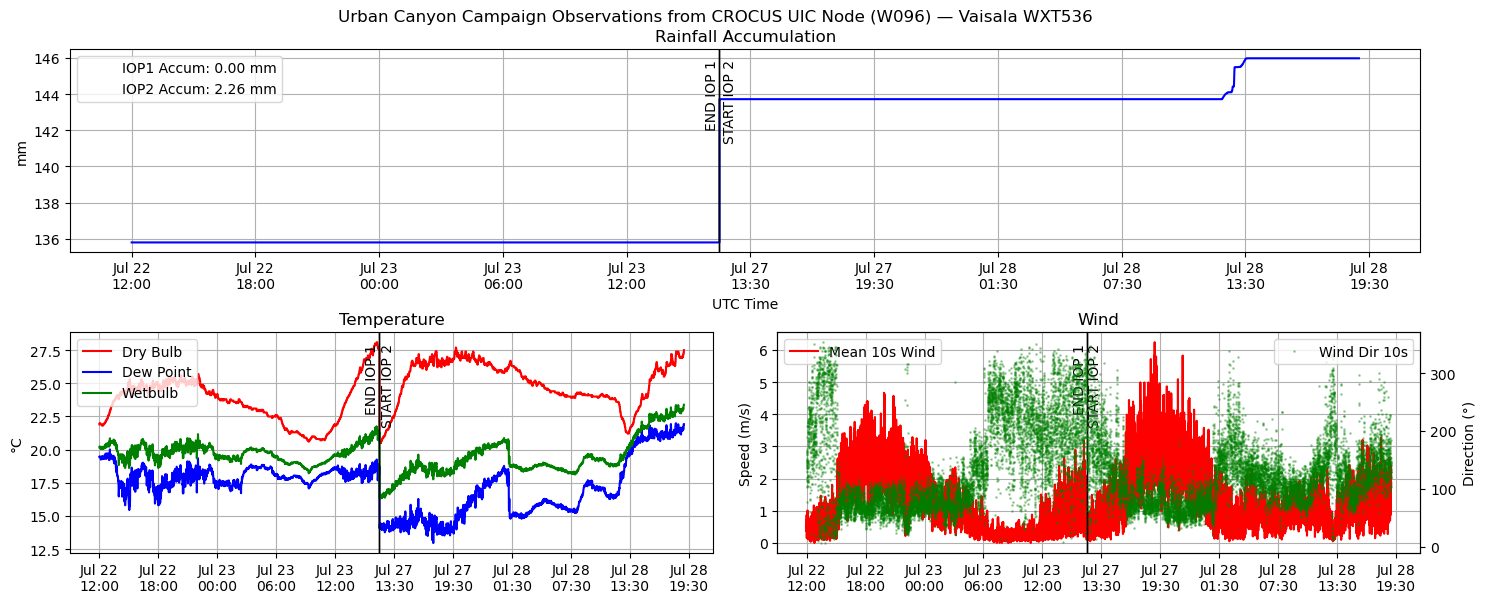

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
import matplotlib.lines as mlines
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from datetime import datetime
import pytz

data = ds_all

# Define IOP segments and splice
seg1 = data.sel(time=slice("2024-07-22T12:00:00", "2024-07-23T16:30:00"))
seg2 = data.sel(time=slice("2024-07-27T12:00:00", "2024-07-28T19:00:00"))
gap_ns = seg2.time.min().values - seg1.time.max().values
gap_pd = pd.Timedelta(gap_ns)
seg2_shifted = seg2.assign_coords(time=seg2.time - gap_ns)
spliced = xr.concat([seg1, seg2_shifted], dim="time")

# Splice boundaries for vlines
t_end_iop1 = pd.to_datetime(seg1.time.max().values).to_pydatetime().replace(tzinfo=None)
t_start_iop2 = (
    pd.to_datetime(seg2_shifted.time.min().values).to_pydatetime().replace(tzinfo=None)
)

ra1 = seg1.rainfall.values[-1] - seg1.rainfall.values[0]
ra2 = seg2.rainfall.values[-1] - seg2.rainfall.values[0]

central = pytz.timezone("America/Chicago")
current_time_ct = datetime.now(central).strftime("%Y-%m-%d %H:%M:%S %Z")

fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.1, 1.2], hspace=0.38)

# Top: Rainfall
ax_rain = fig.add_subplot(gs[0, :])
spliced.rainfall.plot(ax=ax_rain, color="b", label="_nolegend_")
h_ra1 = mlines.Line2D([], [], color="none", label=f"IOP1 Accum: {ra1:.2f} mm")
h_ra2 = mlines.Line2D([], [], color="none", label=f"IOP2 Accum: {ra2:.2f} mm")
ax_rain.set_title("Rainfall Accumulation")
ax_rain.set_ylabel("mm")
ax_rain.set_xlabel("UTC Time")
ax_rain.legend(handles=[h_ra1, h_ra2], loc="upper left")
ax_rain.grid(True)

# Bottom left: Temperature
ax_temp = fig.add_subplot(gs[1, 0])
spliced.temperature.plot(ax=ax_temp, color="r", label="Dry Bulb")
spliced.dewpoint.plot(ax=ax_temp, color="b", label="Dew Point")
spliced.wetbulb.plot(ax=ax_temp, color="g", label="Wetbulb")
ax_temp.set_title("Temperature")
ax_temp.set_ylabel("°C")
ax_temp.legend(loc="upper left")
ax_temp.grid(True)

# Bottom right: Wind
ax_wind = fig.add_subplot(gs[1, 1])
spliced.wind_mean_10s.plot(ax=ax_wind, color="r", label="Mean 10s Wind")
yt = ax_wind.twinx()
spliced.wind_dir_10s.plot(
    ax=yt,
    color="g",
    label="Wind Dir 10s",
    marker=".",
    linestyle="none",
    markersize=2,
    alpha=0.3,
)
ax_wind.set_title("Wind")
ax_wind.set_ylabel("Speed (m/s)")
yt.set_ylabel("Direction (°)")
ax_wind.legend(loc="upper left")
yt.legend(loc="upper right")
ax_wind.grid(True)


def original_time_formatter(x, pos=None):
    dt = mdates.num2date(x).replace(tzinfo=None)
    if dt <= t_end_iop1:
        orig = dt
    else:
        orig = dt + gap_pd
    return orig.strftime("%b %d\n%H:%M")


for ax in (ax_temp, ax_wind, ax_rain):
    ax.xaxis.set_major_formatter(FuncFormatter(original_time_formatter))
    if ax is not ax_rain:
        ax.set_xlabel("")

# Small offset so text doesn't overlap the vline for START IOP 2
x_offset = pd.Timedelta(minutes=10)

for ax in (ax_temp, ax_wind, ax_rain):
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    # END IOP 1: left/top label
    ax.axvline(t_end_iop1, color="k", linestyle="-", linewidth=1)
    ax.text(
        t_end_iop1,
        0.95,
        "END IOP 1",
        transform=trans,
        rotation=90,
        va="top",
        ha="right",
        fontsize=10,
        color="k",
    )
    # START IOP 2: right/top label, shifted right
    ax.axvline(t_start_iop2, color="k", linestyle="-", linewidth=1)
    ax.text(
        t_start_iop2 + x_offset,
        0.95,
        "START IOP 2",
        transform=trans,
        rotation=90,
        va="top",
        ha="left",
        fontsize=10,
        color="k",
    )

fig.subplots_adjust(
    top=0.79, bottom=0.16, left=0.07, right=0.97, hspace=0.38, wspace=0.10
)

node_id = spliced.site_ID
wsn = spliced.WSN
fig.suptitle(
    f"Urban Canyon Campaign Observations from CROCUS UIC Node ({wsn}) — Vaisala WXT536",
    y=0.84,
)

plt.savefig(
    "UIC_Node_WXT_spliced_rain_top_2x2_vlines_offset.png", dpi=300, bbox_inches="tight"
)
plt.show()

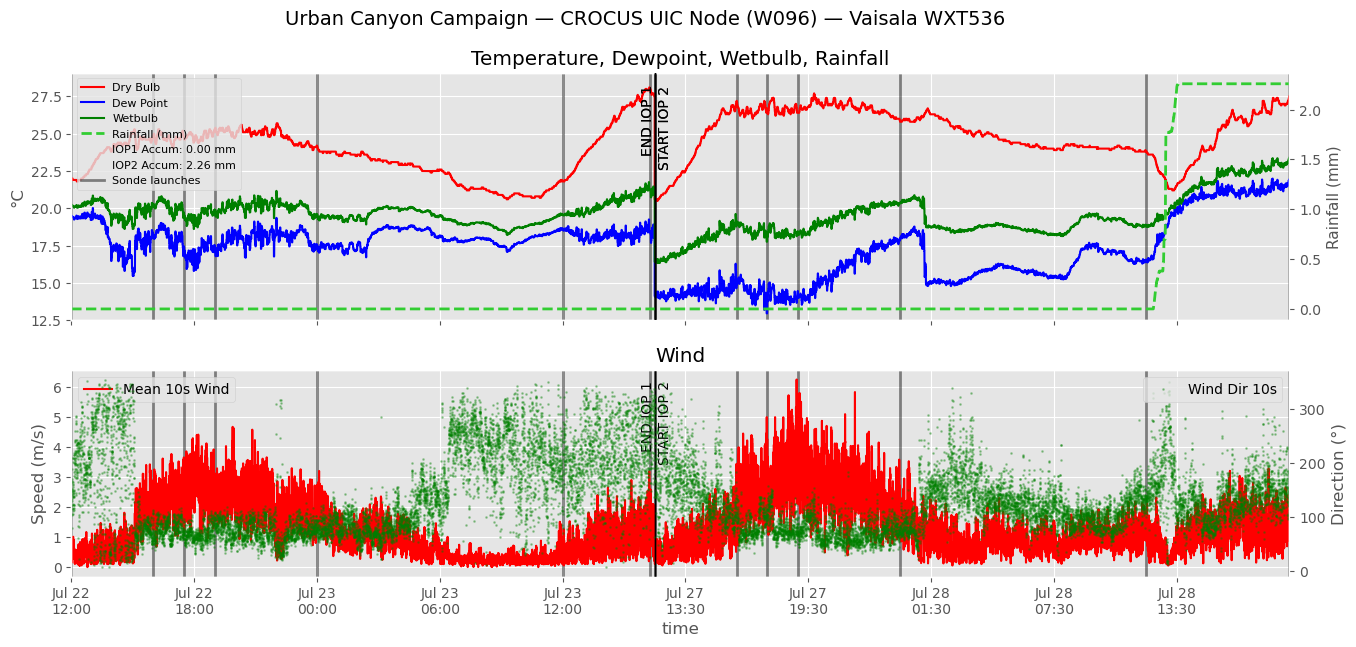

In [30]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
import matplotlib.lines as mlines
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from datetime import datetime
import pytz

plt.style.use('ggplot')
data = ds_all

# Define IOP segments and splice, and reset rainfall at each start
seg1 = data.sel(time=slice("2024-07-22T12:00:00", "2024-07-23T16:30:00")).copy()
seg2 = data.sel(time=slice("2024-07-27T12:00:00", "2024-07-28T19:00:00")).copy()

# Reset rainfall to zero at each IOP start
rain1 = seg1.rainfall - seg1.rainfall.isel(time=0)
rain2 = seg2.rainfall - seg2.rainfall.isel(time=0)

gap_ns = seg2.time.min().values - seg1.time.max().values
gap_pd = pd.Timedelta(gap_ns)
seg2_shifted = seg2.assign_coords(time=seg2.time - gap_ns)
rain2_shifted = rain2.copy()
rain2_shifted['time'] = seg2_shifted.time  # match shifted time

# Concatenate for spliced plot
spliced = xr.concat([seg1, seg2_shifted], dim="time")
spliced_rain = xr.concat([rain1, rain2_shifted], dim="time")

# For vlines/annotations
t_end_iop1 = pd.to_datetime(seg1.time.max().values).to_pydatetime().replace(tzinfo=None)
t_start_iop2 = pd.to_datetime(seg2_shifted.time.min().values).to_pydatetime().replace(tzinfo=None)
ra1 = rain1.values[-1]
ra2 = rain2.values[-1]

# Time bounds for tight xlim
time_min = spliced.time.min().values
time_max = spliced.time.max().values

fig, (ax_temp, ax_wind) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios":[1.2,1]})

# --- Top: Temp, Dew, Wetbulb ---
l1 = spliced.temperature.plot(ax=ax_temp, color="r", label="Dry Bulb", zorder=2)
l2 = spliced.dewpoint.plot(ax=ax_temp, color="b", label="Dew Point", zorder=2)
l3 = spliced.wetbulb.plot(ax=ax_temp, color="g", label="Wetbulb", zorder=2)

# Twin y-axis for Rainfall
ax_rain = ax_temp.twinx()
l_rain, = ax_rain.plot(spliced_rain.time.values, spliced_rain.values, ls='--', color='limegreen', label="Rainfall (mm)", linewidth=2, zorder=2)
ax_rain.set_ylabel("Rainfall (mm)", fontsize=11)
ax_rain.tick_params(axis='y')
ax_rain.grid(False)  # only want one set of grid lines

# Rainfall accumulation (legend only)
h_ra1 = mlines.Line2D([], [], color="none", label=f"IOP1 Accum: {ra1:.2f} mm")
h_ra2 = mlines.Line2D([], [], color="none", label=f"IOP2 Accum: {ra2:.2f} mm")

# Sonde launch times (as in your list)
sonde_times = [
    "2024-07-22T12:00:00", "2024-07-22T16:00:00", "2024-07-22T17:30:00", "2024-07-22T19:00:00",
    "2024-07-23T00:00:00", "2024-07-23T12:00:00", "2024-07-23T16:15:00",
    "2024-07-27T12:00:00", "2024-07-27T16:00:00", "2024-07-27T17:30:00", "2024-07-27T19:00:00",
    "2024-07-28T00:00:00", "2024-07-28T12:00:00", "2024-07-28T19:00:00"
]

# --- Bottom: Wind/Direction ---
l4 = spliced.wind_mean_10s.plot(ax=ax_wind, color="r", label="Mean 10s Wind", zorder=2)
yt = ax_wind.twinx()
l5 = spliced.wind_dir_10s.plot(
    ax=yt,
    color="g",
    label="Wind Dir 10s",
    marker=".",
    linestyle="none",
    markersize=2,
    alpha=0.3,
    zorder=2,
)
ax_wind.set_title("Wind")
ax_wind.set_ylabel("Speed (m/s)")
yt.set_ylabel("Direction (°)")
ax_wind.legend(loc="upper left", fontsize=10)
yt.legend(loc="upper right", fontsize=10)
ax_wind.grid(True, zorder=0)
yt.grid(False)

# --- Formatters, vlines, tight axis
def original_time_formatter(x, pos=None):
    dt = mdates.num2date(x).replace(tzinfo=None)
    if dt <= t_end_iop1:
        orig = dt
    else:
        orig = dt + gap_pd
    return orig.strftime("%b %d\n%H:%M")

for ax in (ax_temp, ax_wind, ax_rain):
    ax.xaxis.set_major_formatter(FuncFormatter(original_time_formatter))
    ax.set_xlim([time_min, time_max])

# ----------- FIXED SONDE LINES LOGIC -------------
# Calculate plot-time for each sonde launch
sonde_plot_times = []
for tstr in sonde_times:
    t = pd.to_datetime(tstr)
    if t >= pd.to_datetime("2024-07-27T00:00:00"):
        # Find closest time index in seg2.time
        idx = np.argmin(np.abs(seg2.time.values - np.datetime64(t)))
        t_plot = pd.to_datetime(seg2_shifted.time.values[idx])
    else:
        t_plot = t
    sonde_plot_times.append(t_plot)

# Now plot all lines at these times
sonde_line = None
for i, t_plot in enumerate(sonde_plot_times):
    label = "Sonde launches" if i == 0 else None
    for ax in (ax_temp, ax_wind):
        l = ax.axvline(
            t_plot, color="k", linestyle="-", linewidth=2, alpha=0.45, zorder=1, label=label
        )
        if label is not None:
            sonde_line = l  # For legend

# ----------------------------------------------

x_offset = pd.Timedelta(minutes=10)
for ax in (ax_temp, ax_wind, ax_rain):
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    # END IOP 1: left/top label
    ax.axvline(t_end_iop1, color="k", linestyle="-", linewidth=1, zorder=3)
    ax.text(
        t_end_iop1, 0.95, "END IOP 1",
        transform=trans, rotation=90, va="top", ha="right",
        fontsize=10, color="k", zorder=4
    )
    # START IOP 2: right/top label, shifted right
    ax.axvline(t_start_iop2, color="k", linestyle="-", linewidth=1, zorder=3)
    ax.text(
        t_start_iop2 + x_offset, 0.95, "START IOP 2",
        transform=trans, rotation=90, va="top", ha="left",
        fontsize=10, color="k", zorder=4
    )

# Custom legend handles for ax_temp
handles = [
    l1[0],  # Dry Bulb
    l2[0],  # Dew Point
    l3[0],  # Wetbulb
    l_rain, # Rainfall
    h_ra1, h_ra2,
    sonde_line
]
labels = [
    "Dry Bulb", "Dew Point", "Wetbulb", "Rainfall (mm)", f"IOP1 Accum: {ra1:.2f} mm", f"IOP2 Accum: {ra2:.2f} mm", "Sonde launches"
]
ax_temp.legend(handles, labels, loc="upper left", fontsize=8)
ax_temp.set_title("Temperature, Dewpoint, Wetbulb, Rainfall")
ax_temp.set_ylabel("°C")
ax_temp.set_xlabel("")
ax_temp.grid(True, zorder=0)
ymin = float(spliced.temperature.min()) - 8
ymax = float(spliced.temperature.max()) + 1
ax_temp.set_ylim(ymin, ymax)

fig.subplots_adjust(
    top=0.85, bottom=0.13, left=0.09, right=0.96, hspace=0.22
)

node_id = spliced.site_ID
wsn = spliced.WSN
fig.suptitle(
    f"Urban Canyon Campaign — CROCUS UIC Node ({wsn}) — Vaisala WXT536",
    y=0.94,
    fontsize=14
)

plt.show()
